# NYC Neighborhood Pulse
## Notebook 02 — NLP Processing: spaCy + BERTopic

**Input** : `outputs/merged_reviews.csv`  
**Outputs**: 
- `outputs/neighborhoods_topics.csv` — per-neighborhood topic + metrics (feeds the map)
- `outputs/topic_keywords.json`      — topic labels & top words (feeds the UI)
- `outputs/doc_topics.csv`           — per-review topic assignment (optional deep dive)

## 0. Install Dependencies

In [1]:
# Run once
# !pip install bertopic sentence-transformers spacy umap-learn hdbscan
# !python -m spacy download en_core_web_sm

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np
import os, json
from tqdm import tqdm

BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

df = pd.read_csv(os.path.join(OUTPUT_DIR, 'merged_reviews.csv'))
print(f'Loaded: {len(df):,} reviews, {df["neighborhood"].nunique()} neighborhoods')
df.head(3)

Loaded: 149,903 reviews, 220 neighborhoods


,listing_id,review_id,date,comments,neighborhood,borough,latitude,longitude,room_type
0,683996557814541468,784102372813371668,2022-12-17,2nd time here & 1 of my fave places thus far d...,Allerton,Bronx,40.868370,-73.853390,Entire home/apt
1,37325442,1117464005622811699,2024-03-21,O espaço é exatamente como nas fotos e na desc...,Allerton,Bronx,40.862370,-73.852780,Private room
2,835034745398769498,871803923748234436,2023-04-17,Nice quiet apartment that’s close to the subwa...,Allerton,Bronx,40.867471,-73.861057,Entire home/apt


## 2. Text Cleaning with spaCy

In [3]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])  # only need tokenizer + lemmatizer

# Generic Airbnb filler words to remove
CUSTOM_STOPWORDS = {
    'apartment', 'place', 'stay', 'host', 'airbnb', 'room', 'nyc',
    'new', 'york', 'city', 'great', 'good', 'nice', 'clean', 'recommend',
    'definitely', 'highly', 'perfect', 'excellent', 'amazing', 'wonderful',
    'comfortable', 'listing', 'guest', 'arrival', 'check', 'location'
}

def clean_text(text):
    """Lemmatize, remove stopwords and noise."""
    doc = nlp(str(text).lower())
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
        and len(token) > 2
        and token.lemma_ not in CUSTOM_STOPWORDS
    ]
    return ' '.join(tokens)

print('Cleaning text with spaCy... (may take 3-5 min)')
tqdm.pandas()
df['text_clean'] = df['comments'].progress_apply(clean_text)

# Drop rows that became too short after cleaning
df = df[df['text_clean'].str.split().str.len() >= 5]
print(f'After cleaning: {len(df):,} reviews remain')

Cleaning text with spaCy... (may take 3-5 min)


100%|██████████████████████████████████| 149903/149903 [11:47<00:00, 211.78it/s]


After cleaning: 130,150 reviews remain


In [4]:
# Preview
print('Original:', df['comments'].iloc[0][:200])
print('\nCleaned :', df['text_clean'].iloc[0])

Original: 2nd time here & 1 of my fave places thus far during my travel contract, to stay. Clean, good value, AND street parking hasn’t been difficult!!! It’s such a relief!! Thank you!!

Cleaned : time fave far travel contract value street parking difficult relief thank


## 3. BERTopic — Discover Neighborhood Topics

BERTopic pipeline:
1. **Sentence embeddings** (all-MiniLM-L6-v2) — turns text into vectors  
2. **UMAP** — reduces dimensions  
3. **HDBSCAN** — clusters similar reviews  
4. **c-TF-IDF** — extracts representative keywords per cluster  

In [5]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import KMeans          # ← 换成 KMeans
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# KMeans 保证找到固定数量的 topic，不会出现0个cluster的情况
cluster_model = KMeans(n_clusters=10, random_state=42)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,    # ← KMeans 替代 HDBSCAN
    vectorizer_model=vectorizer_model,
    nr_topics=10,
    calculate_probabilities=False,  # ← 避免额外计算错误
    verbose=True
)

print('Model configured with KMeans clustering (guaranteed 10 topics)')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model configured with KMeans clustering (guaranteed 10 topics)


In [ ]:
# ── Fit the model ────────────────────────────────────────
# This is the heavy step: ~10-20 min on CPU, ~3-5 min on GPU
docs = df['text_clean'].tolist()

topics, probs = topic_model.fit_transform(docs)

df['topic_id'] = topics
print(f'\nDone! Discovered {topic_model.get_topic_info().shape[0] - 1} topics')
print(f'Docs assigned to topics (not outliers): {(np.array(topics) != -1).sum():,}')

2026-04-14 21:32:52,472 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/4068 [00:00<?, ?it/s]

2026-04-14 21:40:15,856 - BERTopic - Embedding - Completed ✓
2026-04-14 21:40:15,856 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 21:41:51,038 - BERTopic - Dimensionality - Completed ✓
2026-04-14 21:41:51,042 - BERTopic - Cluster - Start clustering the reduced embeddings


## 4. Inspect & Label Topics

In [ ]:
topic_info = topic_model.get_topic_info()
print(topic_info[topic_info['Topic'] != -1].head(20).to_string())

In [ ]:
# Print top keywords for each topic — use these to manually name topics
for topic_id in topic_info['Topic']:
    if topic_id == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(topic_id)[:8]]
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f'Topic {topic_id:3d} ({count:5,} docs): {" | ".join(words)}')

In [ ]:
# ── Manually assign human-readable labels ────────────────
# After reading the keywords above, fill in this dict
# Example labels — UPDATE THESE based on what you see above!

TOPIC_LABELS = {
    # topic_id : 'Label'
    0:  'Transit & Commute',
    1:  'Food & Restaurants',
    2:  'Safety & Neighborhood Vibe',
    3:  'Parks & Outdoor Life',
    4:  'Nightlife & Entertainment',
    5:  'Arts & Culture',
    6:  'Shopping & Retail',
    7:  'Families & Community',
    8:  'Luxury & Upscale',
    9:  'Diversity & Local Character',
    -1: 'Unclassified'
}

# Add any extra topics discovered (ID > 9)
all_topic_ids = topic_info[topic_info['Topic'] != -1]['Topic'].tolist()
for tid in all_topic_ids:
    if tid not in TOPIC_LABELS:
        words = [w for w, _ in topic_model.get_topic(tid)[:3]]
        TOPIC_LABELS[tid] = ' & '.join(words).title()

df['topic_label'] = df['topic_id'].map(TOPIC_LABELS).fillna('Other')
print('Topic labels mapped.')
print(df['topic_label'].value_counts())

## 5. Aggregate by Neighborhood — create the map data

In [ ]:
# For each neighborhood: dominant topic, review count, topic distribution
df_valid = df[df['topic_id'] != -1].copy()

# Dominant topic per neighborhood
dominant = (
    df_valid
    .groupby(['neighborhood', 'borough', 'topic_id', 'topic_label'])
    .size()
    .reset_index(name='topic_count')
    .sort_values('topic_count', ascending=False)
    .groupby('neighborhood')
    .first()
    .reset_index()
    .rename(columns={
        'topic_id': 'dominant_topic_id',
        'topic_label': 'dominant_topic_label'
    })
)

# Total review count per neighborhood
counts = df.groupby('neighborhood').size().reset_index(name='review_count')

# Representative center of each neighborhood (median lat/lon)
centers = (
    df.groupby('neighborhood')
    .agg(lat=('latitude', 'median'), lon=('longitude', 'median'))
    .reset_index()
)

# Top 5 keywords per neighborhood
def top_keywords(group, n=5):
    from collections import Counter
    words = ' '.join(group['text_clean'].tolist()).split()
    common = Counter(words).most_common(n)
    return ', '.join([w for w, _ in common])

print('Extracting top keywords per neighborhood... (takes ~1 min)')
keywords = (
    df.groupby('neighborhood')
    .apply(top_keywords)
    .reset_index(name='top_keywords')
)

# Merge all
neigh_df = (
    dominant
    .merge(counts,   on='neighborhood')
    .merge(centers,  on='neighborhood')
    .merge(keywords, on='neighborhood')
)

print(f'Neighborhood summary: {len(neigh_df)} neighborhoods')
neigh_df.head(5)

## 6. Save Outputs

In [ ]:
# 6a. Neighborhood-level map data
neigh_df.to_csv(os.path.join(OUTPUT_DIR, 'neighborhoods_topics.csv'), index=False)
print('✅ Saved: neighborhoods_topics.csv')

# 6b. Topic keywords dict (for UI labels)
topic_keywords_dict = {}
for tid in all_topic_ids:
    label = TOPIC_LABELS.get(tid, f'Topic {tid}')
    words = [w for w, _ in topic_model.get_topic(tid)[:10]]
    topic_keywords_dict[str(tid)] = {
        'label': label,
        'keywords': words
    }

with open(os.path.join(OUTPUT_DIR, 'topic_keywords.json'), 'w') as f:
    json.dump(topic_keywords_dict, f, indent=2)
print('✅ Saved: topic_keywords.json')

# 6c. Per-document topic (for detailed analysis)
df[['review_id','listing_id','neighborhood','borough','date','topic_id','topic_label']].to_csv(
    os.path.join(OUTPUT_DIR, 'doc_topics.csv'), index=False
)
print('✅ Saved: doc_topics.csv')

## 7. Quick Visual Check — Topic Distribution

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

topic_counts = df_valid['topic_label'].value_counts().head(15)
colors = cm.plasma(np.linspace(0.1, 0.9, len(topic_counts)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(topic_counts.index, topic_counts.values, color=colors)
ax.set_xticklabels(topic_counts.index, rotation=45, ha='right')
ax.set_title('Review Count by Topic', fontsize=14)
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'topic_distribution.png'), dpi=150)
plt.show()

In [ ]:
# Borough × Topic heatmap
pivot = (
    df_valid
    .groupby(['borough', 'topic_label'])
    .size()
    .unstack(fill_value=0)
)
# Normalize by row
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot_norm.values, cmap='plasma', aspect='auto')
ax.set_xticks(range(len(pivot_norm.columns)))
ax.set_xticklabels(pivot_norm.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_norm.index)))
ax.set_yticklabels(pivot_norm.index)
ax.set_title('Topic Distribution by Borough (normalized)', fontsize=13)
plt.colorbar(im, ax=ax, label='Proportion')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'borough_topic_heatmap.png'), dpi=150)
plt.show()

---
## ✅ Notebook 02 Complete

**Files ready in `outputs/`:**
- `neighborhoods_topics.csv` → feeds PyDeck map
- `topic_keywords.json`      → feeds Streamlit sidebar
- `doc_topics.csv`           → optional deep-dive

**Next**: Run `03_viz_prototype.ipynb` to preview the map before building Streamlit.

In [1]:
# ── 轻量替代方案：TF-IDF + SVD + KMeans（无需 sentence-transformers）──
import pandas as pd
import numpy as np
import os, json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

# 重新加载数据（kernel 重启后变量丢失）
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'merged_reviews.csv'))
df = df.dropna(subset=['comments'])
print(f'Loaded: {len(df):,} reviews')

# 用 comments 原文（跳过 spaCy 清洗节省内存）
docs = df['comments'].fillna('').tolist()
print('Starting TF-IDF vectorization...')

# Step 1: TF-IDF
vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5, max_df=0.85
)
X = vectorizer.fit_transform(docs)
print(f'TF-IDF matrix: {X.shape}')

# Step 2: 降维
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X)
print('SVD done.')

# Step 3: KMeans 聚类
N_TOPICS = 10
km = KMeans(n_clusters=N_TOPICS, random_state=42, n_init=10)
topics = km.fit_predict(X_svd)
df['topic_id'] = topics
print(f'\nDone! Topic distribution:')
print(pd.Series(topics).value_counts().sort_index())

Loaded: 149,903 reviews
Starting TF-IDF vectorization...
TF-IDF matrix: (149903, 3000)
SVD done.

Done! Topic distribution:
0     6044
1    10620
2    25234
3     5084
4     9142
5    65541
6    13106
7     2887
8     5633
9     6612
Name: count, dtype: int64


In [2]:
# 查看每个 topic 的关键词
feature_names = vectorizer.get_feature_names_out()

print('=== Topic Keywords ===\n')
for tid in range(N_TOPICS):
    mask = topics == tid
    # 该 topic 所有文档的平均 TF-IDF
    topic_vec = X[mask].mean(axis=0).A1
    top_idx   = topic_vec.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    count = mask.sum()
    print(f'Topic {tid:2d} ({count:5,} docs): {" | ".join(top_words[:8])}')

=== Topic Keywords ===

Topic  0 (6,044 docs): muy | el | la | en | es | que | para | todo
Topic  1 (10,620 docs): br | place | stay | great | apartment | room | clean | host
Topic  2 (25,234 docs): great | location | great location | stay | place | great place | host | great stay
Topic  3 (5,084 docs): enjoyed | enjoyed stay | stay | really enjoyed | really | place | great | clean
Topic  4 (9,142 docs): home | felt | like | stay | right home | like home | place | feel
Topic  5 (65,541 docs): stay | place | clean | apartment | host | location | room | comfortable
Topic  6 (13,106 docs): nice | place | stay | clean | nice place | great | room | really
Topic  7 (2,887 docs): und | die | sehr | ist | war | wir | der | zu
Topic  8 (5,633 docs): et | très | est | le | nous | pour | la | br
Topic  9 (6,612 docs): new york | york | new | stay | place | great | city | apartment


In [3]:
TOPIC_LABELS = {
    0: 'Spanish-Speaking Visitors',
    1: 'Clean & Comfortable Stay',
    2: 'Great Location & Transit',
    3: 'Truly Enjoyable Experience',
    4: 'Feels Like Home',
    5: 'Practical Comfort',
    6: 'Nice & Pleasant Place',
    7: 'German-Speaking Visitors',
    8: 'French-Speaking Visitors',
    9: 'NYC City Experience',
}

df['topic_label'] = df['topic_id'].map(TOPIC_LABELS)
print(df['topic_label'].value_counts())

topic_label
Practical Comfort             65541
Great Location & Transit      25234
Nice & Pleasant Place         13106
Clean & Comfortable Stay      10620
Feels Like Home                9142
NYC City Experience            6612
Spanish-Speaking Visitors      6044
French-Speaking Visitors       5633
Truly Enjoyable Experience     5084
German-Speaking Visitors       2887
Name: count, dtype: int64


In [4]:
# 按社区聚合 → 生成地图数据
from collections import Counter

df_valid = df.copy()

dominant = (
    df_valid.groupby(['neighborhood', 'borough', 'topic_id', 'topic_label'])
    .size().reset_index(name='topic_count')
    .sort_values('topic_count', ascending=False)
    .groupby('neighborhood').first().reset_index()
    .rename(columns={'topic_id': 'dominant_topic_id',
                     'topic_label': 'dominant_topic_label'})
)

counts = df.groupby('neighborhood').size().reset_index(name='review_count')

centers = (
    df.groupby('neighborhood')
    .agg(lat=('latitude', 'median'), lon=('longitude', 'median'))
    .reset_index()
)

def top_keywords(group, n=5):
    words = ' '.join(group['comments'].fillna('').str.lower().tolist()).split()
    common = Counter(w for w in words if len(w) > 3)
    return ', '.join([w for w, _ in common.most_common(n)])

print('Extracting keywords...')
keywords = df.groupby('neighborhood').apply(top_keywords).reset_index(name='top_keywords')

neigh_out = (dominant
    .merge(counts, on='neighborhood')
    .merge(centers, on='neighborhood')
    .merge(keywords, on='neighborhood')
)

neigh_out.to_csv(os.path.join(OUTPUT_DIR, 'neighborhoods_topics.csv'), index=False)
print(f'✅ Saved! {len(neigh_out)} neighborhoods')
print(neigh_out[['neighborhood', 'dominant_topic_label', 'review_count']].head(8))

Extracting keywords...
✅ Saved! 220 neighborhoods
        neighborhood dominant_topic_label  review_count
0           Allerton    Practical Comfort           283
1      Arden Heights    Practical Comfort            12
2           Arrochar    Practical Comfort           103
3            Arverne    Practical Comfort           463
4            Astoria    Practical Comfort          2457
5         Bath Beach    Practical Comfort           217
6  Battery Park City    Practical Comfort            15
7          Bay Ridge    Practical Comfort           414


/var/folders/d8/p3l6lrbx3t99x52zv7k2tnmm0000gn/T/ipykernel_88425/1583481722.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  keywords = df.groupby('neighborhood').apply(top_keywords).reset_index(name='top_keywords')


In [5]:
# 计算每个社区最具辨识度的 topic（TF-IDF 思路）
topic_counts_per_neigh = (
    df.groupby(['neighborhood', 'topic_label'])
    .size().reset_index(name='count')
)

# 全市各 topic 的平均比例
city_total = df.shape[0]
city_topic_ratio = (
    df['topic_label'].value_counts() / city_total
).to_dict()

# 每个社区的 topic 比例 ÷ 全市比例 = 辨识度得分
topic_counts_per_neigh['neigh_total'] = topic_counts_per_neigh.groupby(
    'neighborhood')['count'].transform('sum')
topic_counts_per_neigh['neigh_ratio'] = (
    topic_counts_per_neigh['count'] / topic_counts_per_neigh['neigh_total']
)
topic_counts_per_neigh['city_ratio'] = topic_counts_per_neigh['topic_label'].map(
    city_topic_ratio
)
topic_counts_per_neigh['distinctiveness'] = (
    topic_counts_per_neigh['neigh_ratio'] / topic_counts_per_neigh['city_ratio']
)

# 每个社区取辨识度最高的 topic
distinctive = (
    topic_counts_per_neigh
    .sort_values('distinctiveness', ascending=False)
    .groupby('neighborhood').first()
    .reset_index()
    [['neighborhood', 'topic_label', 'distinctiveness']]
    .rename(columns={'topic_label': 'dominant_topic_label'})
)

# 合并回去
neigh_out2 = (
    distinctive
    .merge(counts,   on='neighborhood')
    .merge(centers,  on='neighborhood')
    .merge(keywords, on='neighborhood')
)

neigh_out2.to_csv(os.path.join(OUTPUT_DIR, 'neighborhoods_topics.csv'), index=False)
print('✅ Saved with distinctiveness-based topics!')
print(neigh_out2['dominant_topic_label'].value_counts())

✅ Saved with distinctiveness-based topics!
dominant_topic_label
Feels Like Home               63
Spanish-Speaking Visitors     27
Nice & Pleasant Place         25
Truly Enjoyable Experience    23
German-Speaking Visitors      23
Great Location & Transit      16
Clean & Comfortable Stay      15
French-Speaking Visitors      12
NYC City Experience           10
Practical Comfort              6
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ── 加载数据 ───────────────────────────────────────────────────────────────────
doc_topics = pd.read_csv('outputs/doc_topics.csv')
neigh_info = pd.read_csv('outputs/neighborhoods_topics.csv')  # 含 dominant_topic_label, review_count, lat, lon

print(f'Documents: {len(doc_topics):,}')
print(f'Neighborhoods: {doc_topics["neighborhood"].nunique()}')

# ── 每个 neighborhood × topic 的文档数量 ──────────────────────────────────────
topic_matrix = (
    doc_topics.groupby(['neighborhood', 'topic_id'])
    .size()
    .unstack(fill_value=0)
)

# 转为比例（行归一化）→ 每个 neighborhood 的 topic 概率分布
topic_probs = topic_matrix.div(topic_matrix.sum(axis=1), axis=0)

print(f'\nTopic matrix shape: {topic_probs.shape}')
print(topic_probs.head(3))

Documents: 130,150
Neighborhoods: 219

Topic matrix shape: (219, 11)
topic_id             -1         0         1         2         3         4  \
neighborhood                                                                
Allerton       0.008511  0.910638  0.025532  0.038298  0.008511  0.004255   
Arden Heights  0.000000  1.000000  0.000000  0.000000  0.000000  0.000000   
Arrochar       0.000000  0.949367  0.037975  0.000000  0.000000  0.012658   

topic_id              5    6    7    8    9  
neighborhood                                 
Allerton       0.004255  0.0  0.0  0.0  0.0  
Arden Heights  0.000000  0.0  0.0  0.0  0.0  
Arrochar       0.000000  0.0  0.0  0.0  0.0  


In [7]:
import networkx as nx

# ── Cosine similarity 矩阵 (220 × 220) ────────────────────────────────────────
neighborhoods = topic_probs.index.tolist()
sim_matrix = cosine_similarity(topic_probs.values)
sim_df = pd.DataFrame(sim_matrix, index=neighborhoods, columns=neighborhoods)

# ── 每个节点只保留 top-4 最相似的边（避免 hairball）─────────────────────────────
K = 4
edges = []
for neigh in neighborhoods:
    row = sim_df[neigh].drop(neigh)          # 排除自身
    top_k = row.nlargest(K)
    for target, weight in top_k.items():
        if weight > 0.5:                     # 相似度阈值
            edges.append({
                'source': neigh,
                'target': target,
                'weight': round(weight, 4)
            })

edges_df = pd.DataFrame(edges).drop_duplicates()
# 去重无向边
edges_df['key'] = edges_df.apply(
    lambda r: tuple(sorted([r['source'], r['target']])), axis=1
)
edges_df = edges_df.drop_duplicates('key').drop(columns='key')

print(f'Edges: {len(edges_df)}')
print(edges_df.head(5))

Edges: 686
          source           target  weight
0       Allerton  Cambria Heights  0.9999
1       Allerton      Parkchester  0.9999
2       Allerton    Fort Hamilton  0.9999
3       Allerton       Bath Beach  0.9998
4  Arden Heights      Bay Terrace  1.0000


In [8]:
# ── 构建 networkx 图 ───────────────────────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(neighborhoods)
for _, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# ── Spring layout（力导向，weight 越大的边拉得越近）────────────────────────────
pos = nx.spring_layout(G, weight='weight', seed=42, k=2.5, iterations=120)

# ── 节点表 ─────────────────────────────────────────────────────────────────────
nodes_df = pd.DataFrame({
    'neighborhood': list(pos.keys()),
    'x': [v[0] for v in pos.values()],
    'y': [v[1] for v in pos.values()],
})

# 合并 dominant topic、review count
nodes_df = nodes_df.merge(
    neigh_info[['neighborhood', 'dominant_topic_label', 'review_count', 'borough']],
    on='neighborhood', how='left'
)

print(f'Nodes: {len(nodes_df)}')
print(nodes_df.head(5))

Nodes: 219
    neighborhood         x         y        dominant_topic_label  \
0       Allerton -0.143964  0.984418  Truly Enjoyable Experience   
1  Arden Heights  0.151889 -0.013975             Feels Like Home   
2       Arrochar -0.635382 -0.745411    Clean & Comfortable Stay   
3        Arverne -0.822166  0.573413             Feels Like Home   
4        Astoria  0.451959  0.089296    French-Speaking Visitors   

   review_count        borough  
0           283          Bronx  
1            12  Staten Island  
2           103  Staten Island  
3           463         Queens  
4          2457         Queens  


PCA variance explained: 68.8%
Edges (top-3, deduplicated): 512


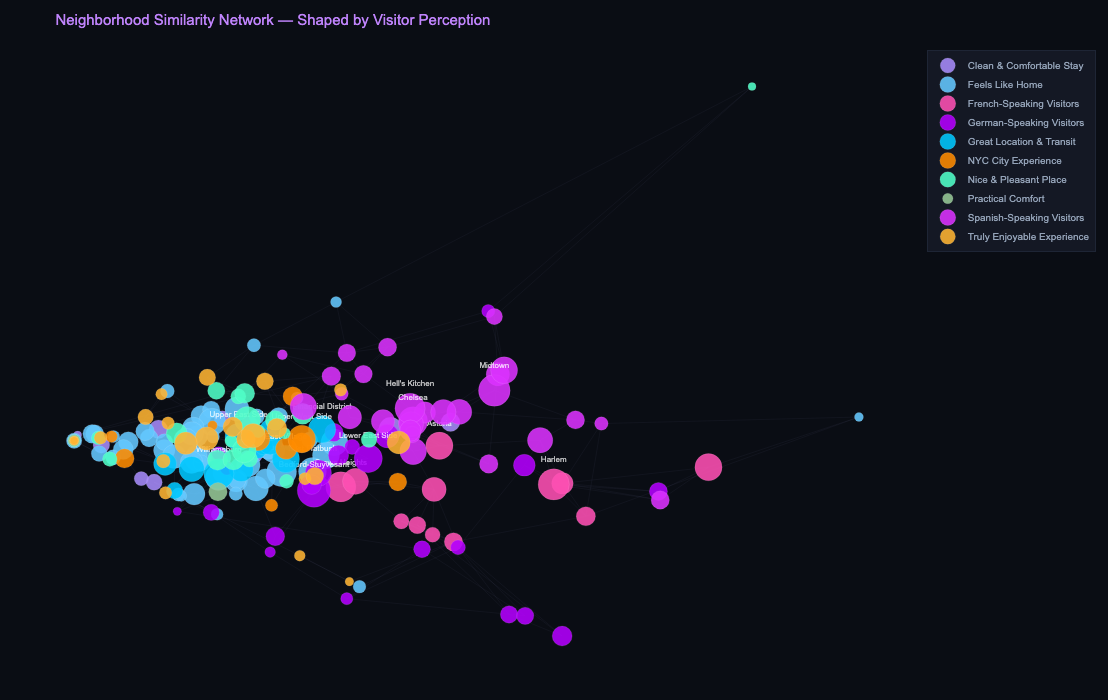

✅ Saved


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import numpy as np
import networkx as nx
import plotly.graph_objects as go

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — 用 topic 向量直接做 PCA 定位
# 相似 topic profile 的 neighborhood 自然聚在一起，不依赖力导向随机性
# ══════════════════════════════════════════════════════════════════════════════
X = normalize(topic_probs.values)  # L2 归一化
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

neighborhoods = topic_probs.index.tolist()
pos_pca = {neigh: (coords[i, 0], coords[i, 1]) for i, neigh in enumerate(neighborhoods)}

print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — 每个节点只连 top-3 最相似邻居，不用全局阈值
# ══════════════════════════════════════════════════════════════════════════════
K = 3
sim_matrix_arr = cosine_similarity(X)
sim_df2 = pd.DataFrame(sim_matrix_arr, index=neighborhoods, columns=neighborhoods)

edges3 = []
for neigh in neighborhoods:
    row = sim_df2[neigh].drop(neigh)
    for target, weight in row.nlargest(K).items():
        edges3.append({'source': neigh, 'target': target, 'weight': round(weight, 4)})

edges3_df = pd.DataFrame(edges3)
edges3_df['key'] = edges3_df.apply(lambda r: tuple(sorted([r['source'], r['target']])), axis=1)
edges3_df = edges3_df.drop_duplicates('key').drop(columns='key')
print(f'Edges (top-3, deduplicated): {len(edges3_df)}')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — 更新 nodes_df 坐标，准备 label 和 size
# ══════════════════════════════════════════════════════════════════════════════
nodes_df['x'] = nodes_df['neighborhood'].map(lambda n: pos_pca[n][0])
nodes_df['y'] = nodes_df['neighborhood'].map(lambda n: pos_pca[n][1])

# Top-15 neighborhoods by review count → 显示标签
top15_labels = set(nodes_df.nlargest(15, 'review_count')['neighborhood'])

# 节点大小：log scale，cap 住最大值
nodes_df['size'] = np.clip(np.log1p(nodes_df['review_count']) * 3.5, 8, 38)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — 画图
# ══════════════════════════════════════════════════════════════════════════════
TOPIC_COLORS = {
    'Great Location & Transit':    '#00c8ff',
    'Spanish-Speaking Visitors':   '#dc32ff',
    'Truly Enjoyable Experience':  '#ffb432',
    'Clean & Comfortable Stay':    '#a78bfa',
    'Feels Like Home':             '#64c8ff',
    'NYC City Experience':         '#ff8c00',
    'German-Speaking Visitors':    '#b400ff',
    'French-Speaking Visitors':    '#ff50b4',
    'Nice & Pleasant Place':       '#50ffc8',
    'Practical Comfort':           '#96c896',
}

fig3 = go.Figure()

# ── 边（极低透明度）─────────────────────────────────────────────────────────
for _, row in edges3_df.iterrows():
    x0, y0 = pos_pca[row['source']]
    x1, y1 = pos_pca[row['target']]
    fig3.add_trace(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=0.8, color=f'rgba(180,180,255,0.06)'),
        hoverinfo='none', showlegend=False,
    ))

# ── 节点（按 topic 分组，保留 legend）────────────────────────────────────────
for topic, grp in nodes_df.groupby('dominant_topic_label'):
    color = TOPIC_COLORS.get(topic, '#888888')

    # 标签：只给 top-15
    labels = grp['neighborhood'].apply(
        lambda n: n if n in top15_labels else ''
    )

    fig3.add_trace(go.Scatter(
        x=grp['x'], y=grp['y'],
        mode='markers+text',
        name=topic,
        marker=dict(
            size=grp['size'],
            color=color,
            opacity=0.88,
            line=dict(width=0.6, color='rgba(255,255,255,0.2)'),
        ),
        text=labels,
        textposition='top center',
        textfont=dict(size=8, color='rgba(255,255,255,0.75)'),
        customdata=grp[['neighborhood', 'borough', 'dominant_topic_label', 'review_count']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            '%{customdata[1]}<br>'
            '<span style="color:#c084fc">%{customdata[2]}</span><br>'
            'Reviews: %{customdata[3]:,}<extra></extra>'
        ),
    ))

fig3.update_layout(
    title=dict(
        text='Neighborhood Similarity Network — Shaped by Visitor Perception',
        font=dict(color='#c084fc', size=15),
    ),
    paper_bgcolor='#0a0d14',
    plot_bgcolor='#0a0d14',
    font=dict(color='#94a3b8', family='Arial'),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=700,
    legend=dict(
        bgcolor='#141824', bordercolor='#1e2535', borderwidth=1,
        font=dict(size=10), title='',
    ),
    margin=dict(l=20, r=20, t=50, b=20),
)

fig3.show()

# ── 保存 ─────────────────────────────────────────────────────────────────────
nodes_df.to_csv('outputs/network_nodes.csv', index=False)
edges3_df.to_csv('outputs/network_edges.csv', index=False)
print('✅ Saved')

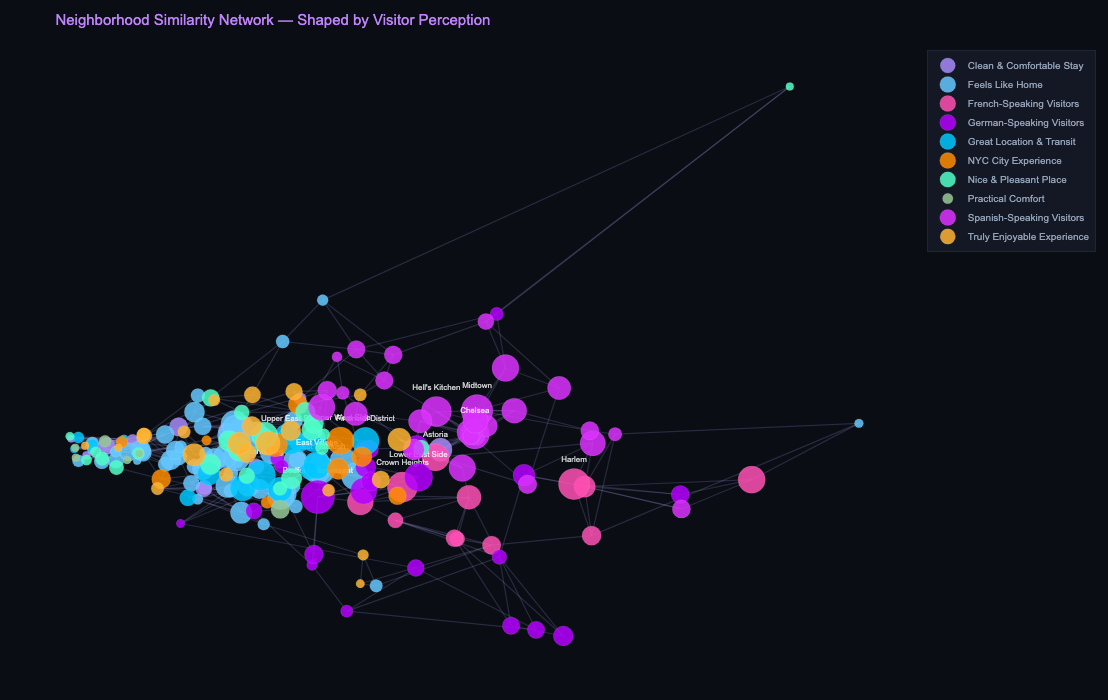

✅ Saved


In [12]:
# ── 拉伸 PCA 坐标，让 cluster 更分散 ─────────────────────────────────────────
scale_x, scale_y = 3.0, 5.0   # y 轴拉更大，把上下分开
np.random.seed(42)
jitter = 0.04  # 微小随机偏移防止完全重叠

nodes_df['x2'] = nodes_df['neighborhood'].map(lambda n: pos_pca[n][0]) * scale_x
nodes_df['y2'] = nodes_df['neighborhood'].map(lambda n: pos_pca[n][1]) * scale_y
nodes_df['x2'] += np.random.uniform(-jitter, jitter, len(nodes_df))
nodes_df['y2'] += np.random.uniform(-jitter, jitter, len(nodes_df))

pos_spread = dict(zip(nodes_df['neighborhood'], zip(nodes_df['x2'], nodes_df['y2'])))

# ── 重画 ──────────────────────────────────────────────────────────────────────
fig4 = go.Figure()

# 边：明显可见但不抢焦点
for _, row in edges3_df.iterrows():
    x0, y0 = pos_spread[row['source']]
    x1, y1 = pos_spread[row['target']]
    fig4.add_trace(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=1.2, color='rgba(180,180,255,0.18)'),
        hoverinfo='none', showlegend=False,
    ))

# 节点
for topic, grp in nodes_df.groupby('dominant_topic_label'):
    color = TOPIC_COLORS.get(topic, '#888888')
    labels = grp['neighborhood'].apply(lambda n: n if n in top15_labels else '')

    fig4.add_trace(go.Scatter(
        x=grp['x2'], y=grp['y2'],
        mode='markers+text',
        name=topic,
        marker=dict(
            size=grp['size'],
            color=color,
            opacity=0.85,
            line=dict(width=0.6, color='rgba(255,255,255,0.2)'),
        ),
        text=labels,
        textposition='top center',
        textfont=dict(size=8, color='rgba(255,255,255,0.8)'),
        customdata=grp[['neighborhood','borough','dominant_topic_label','review_count']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            '%{customdata[1]}<br>'
            '<span style="color:#c084fc">%{customdata[2]}</span><br>'
            'Reviews: %{customdata[3]:,}<extra></extra>'
        ),
    ))

fig4.update_layout(
    title=dict(
        text='Neighborhood Similarity Network — Shaped by Visitor Perception',
        font=dict(color='#c084fc', size=15),
    ),
    paper_bgcolor='#0a0d14', plot_bgcolor='#0a0d14',
    font=dict(color='#94a3b8', family='Arial'),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=700,
    legend=dict(bgcolor='#141824', bordercolor='#1e2535', borderwidth=1, font=dict(size=10), title=''),
    margin=dict(l=20, r=20, t=50, b=20),
)

fig4.show()

# 保存
nodes_df = nodes_df.rename(columns={'x2':'x','y2':'y'})
nodes_df[['neighborhood','x','y','dominant_topic_label','review_count','borough','size']].to_csv(
    'outputs/network_nodes.csv', index=False)
edges3_df.to_csv('outputs/network_edges.csv', index=False)
print('✅ Saved')

In [ ]:
import networkx as nx
from networkx.algorithms import community as nx_community
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# ══════════════════════════════════════════════════════════════════════════════
# DROP any leftover coordinate columns to avoid DuplicateError
# ══════════════════════════════════════════════════════════════════════════════
nodes_df = nodes_df.drop(
    columns=[c for c in ["x","y","x2","y2","viz_size","community","comm_color"] if c in nodes_df.columns]
)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Rebuild graph (top-3 edges per node, no global threshold)
# ══════════════════════════════════════════════════════════════════════════════
G = nx.Graph()
G.add_nodes_from(neighborhoods)
for _, row in edges3_df.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Louvain community detection
# ══════════════════════════════════════════════════════════════════════════════
try:
    comms = nx_community.louvain_communities(G, seed=42, weight="weight")
except AttributeError:
    comms = list(nx_community.greedy_modularity_communities(G, weight="weight"))

MIN_SIZE = 5
main_comms = [c for c in comms if len(c) >= MIN_SIZE]
small_nodes = set().union(*[c for c in comms if len(c) < MIN_SIZE]) if any(len(c) < MIN_SIZE for c in comms) else set()

node_to_comm = {}
for i, c in enumerate(main_comms):
    for n in c:
        node_to_comm[n] = i
for n in small_nodes:
    neighbors_comms = [node_to_comm[nb] for nb in G.neighbors(n) if nb in node_to_comm]
    node_to_comm[n] = max(set(neighbors_comms), key=neighbors_comms.count) if neighbors_comms else 0

n_comms = len(main_comms)
print(f"Communities detected: {n_comms}")
for i, c in enumerate(main_comms):
    print(f"  Community {i}: {len(c)} neighborhoods")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Community colors (5 vivid, distinct)
# ══════════════════════════════════════════════════════════════════════════════
COMM_COLORS = ["#00d4ff", "#ff3fa4", "#ffaa00", "#a855f7", "#22ff88",
               "#ff6030", "#40e0d0", "#f59e0b"]
comm_color_map = {i: COMM_COLORS[i % len(COMM_COLORS)] for i in range(n_comms)}

nodes_df["community"] = nodes_df["neighborhood"].map(node_to_comm)
nodes_df["comm_color"] = nodes_df["community"].map(comm_color_map)

comm_labels = {}
for i in range(n_comms):
    subset = nodes_df[nodes_df["community"] == i]
    comm_labels[i] = subset["dominant_topic_label"].value_counts().index[0]
print("
Community dominant topics:")
for i, label in comm_labels.items():
    print(f"  {i}: {label}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Hero nodes (top-10 review + top-10 betweenness centrality)
# ══════════════════════════════════════════════════════════════════════════════
top_review  = set(nodes_df.nlargest(10, "review_count")["neighborhood"])
centrality  = nx.betweenness_centrality(G, weight="weight")
top_central = set(sorted(centrality, key=centrality.get, reverse=True)[:10])
hero_nodes  = top_review | top_central
print(f"
Hero nodes ({len(hero_nodes)}): {sorted(hero_nodes)}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Assign PCA + stretched coordinates (same as before)
# ══════════════════════════════════════════════════════════════════════════════
nodes_df["x"] = nodes_df["neighborhood"].map(lambda n: pos_spread[n][0])
nodes_df["y"] = nodes_df["neighborhood"].map(lambda n: pos_spread[n][1])

# Node size: log scale, hero nodes 1.6x
nodes_df["viz_size"] = np.clip(np.log1p(nodes_df["review_count"]) * 3.5, 8, 38)
nodes_df.loc[nodes_df["neighborhood"].isin(hero_nodes), "viz_size"] *= 1.6

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Build figure
# ══════════════════════════════════════════════════════════════════════════════
fig5 = go.Figure()

# ── Edges: same-community brighter, cross-community faint ──────────────────
for _, row in edges3_df.iterrows():
    src, tgt = row["source"], row["target"]
    x0, y0 = pos_spread[src]
    x1, y1 = pos_spread[tgt]
    same_comm = node_to_comm.get(src, -1) == node_to_comm.get(tgt, -2)
    alpha = 0.18 if same_comm else 0.05
    fig5.add_trace(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode="lines",
        line=dict(width=1.0 if same_comm else 0.5, color=f"rgba(180,180,255,{alpha})"),
        hoverinfo="none", showlegend=False,
    ))

# ── Nodes: grouped by community, hero nodes have white border ─────────────
for comm_id in sorted(nodes_df["community"].unique()):
    grp = nodes_df[nodes_df["community"] == comm_id]
    color = comm_color_map[comm_id]
    comm_label = comm_labels.get(comm_id, f"Community {comm_id}")

    # Separate hero from regular nodes
    hero_grp    = grp[grp["neighborhood"].isin(hero_nodes)]
    regular_grp = grp[~grp["neighborhood"].isin(hero_nodes)]

    for subset, is_hero in [(regular_grp, False), (hero_grp, True)]:
        if subset.empty:
            continue
        # Only hero nodes always show label; others show label if top-15
        top15 = set(nodes_df.nlargest(15, "review_count")["neighborhood"])
        labels = subset["neighborhood"].apply(lambda n: n if n in (hero_nodes if is_hero else top15) else "")

        fig5.add_trace(go.Scatter(
            x=subset["x"], y=subset["y"],
            mode="markers+text",
            name=comm_label if not is_hero else "",
            showlegend=not is_hero,
            legendgroup=f"comm_{comm_id}",
            marker=dict(
                size=subset["viz_size"],
                color=color,
                opacity=0.92 if is_hero else 0.80,
                line=dict(
                    width=2.5 if is_hero else 0.5,
                    color="white" if is_hero else "rgba(255,255,255,0.15)"
                ),
            ),
            text=labels,
            textposition="top center",
            textfont=dict(
                size=9 if is_hero else 8,
                color="white" if is_hero else "rgba(255,255,255,0.75)"
            ),
            customdata=subset[["neighborhood","borough","dominant_topic_label","review_count"]].values,
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                "%{customdata[1]}<br>"
                "<span style=color:#c084fc>%{customdata[2]}</span><br>"
                "Reviews: %{customdata[3]:,}<extra></extra>"
            ),
        ))

fig5.update_layout(
    title=dict(
        text="Neighborhood Similarity Network — Clusters by Visitor Perception",
        font=dict(color="#c084fc", size=15),
    ),
    paper_bgcolor="#0a0d14", plot_bgcolor="#0a0d14",
    font=dict(color="#94a3b8", family="Arial"),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=750,
    legend=dict(
        bgcolor="#141824", bordercolor="#1e2535", borderwidth=1,
        font=dict(size=10), title=dict(text="Community", font=dict(color="#c084fc"))
    ),
    margin=dict(l=20, r=20, t=55, b=20),
)

fig5.show()
print("✅ Network visualization complete")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Save outputs
# ══════════════════════════════════════════════════════════════════════════════
nodes_out = nodes_df[["neighborhood","x","y","dominant_topic_label",
                       "review_count","borough","viz_size","community","comm_color"]].copy()
nodes_out.to_csv("outputs/network_nodes.csv", index=False)
edges3_df.to_csv("outputs/network_edges.csv", index=False)

# Community summary
comm_summary = []
for i in range(n_comms):
    subset = nodes_df[nodes_df["community"] == i]
    comm_summary.append({
        "community": i,
        "color": comm_color_map[i],
        "dominant_topic": comm_labels[i],
        "size": len(subset),
        "total_reviews": int(subset["review_count"].sum()),
    })
pd.DataFrame(comm_summary).to_csv("outputs/network_communities.csv", index=False)

print(f"Saved: network_nodes.csv ({len(nodes_out)} rows)")
print(f"Saved: network_edges.csv ({len(edges3_df)} rows)")
print(f"Saved: network_communities.csv ({n_comms} communities)")
